In [ ]:
"""
Hopfion initial magnetic configuration generator.

Implements the analytical ansatz from:
  Wang, PRL 123, 147203 (2019) — DOI: 10.1103/PhysRevLett.123.147203

"""

import struct

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from scipy import ndimage

import mumax3PP.ovf as ovf
import mumax3PP.parameters as parameters

In [ ]:
# ---------------------------------------------------------------------------
# Coordinate mapping functions  (Wang PRL 123, 147203)
# ---------------------------------------------------------------------------

def r_func(rho, w_R, R):
    """
    Radial mapping: rho = sqrt(x²+y²) → r ∈ [0, ∞).
    Returns 0 at the origin (rho=0) by the exp limit.
    """
    return (np.exp(rho / w_R) - 1) / (np.exp(R / w_R) - 1)


def z_func(z, w_h, h):
    """
    Vertical mapping: z → z_i ∈ (-∞, ∞).
    z=0 is handled explicitly to avoid 0/0 → NaN.
    The mathematical limit as z→0 is 0.
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        result = (np.abs(z) * (np.exp(np.abs(z) / w_h) - 1)) / (z * (np.exp(h / w_h) - 1))
    # At z=0 both numerator and denominator are 0; the correct limit is 0.
    return np.where(z == 0, 0.0, result)


In [ ]:
# ---------------------------------------------------------------------------
# Vectorised magnetisation components
# ---------------------------------------------------------------------------

def magnetisation(x, y, z, w_R, w_h, h, R):
    """
    Compute the three magnetisation components on a 3-D grid.

    Parameters
    ----------
    x, y, z : 1-D arrays of physical coordinates (metres)
    w_R, w_h, h, R : hopfion shape parameters (metres)

    Returns
    -------
    M : ndarray, shape (1, Nz, Ny, Nx, 3)
        Normalised magnetisation in (t, z, y, x, component) order
        matching the mumax3/OOMMF OVF convention.
    """
    # Build 3-D grids — indexing='ij' gives shape (Nx, Ny, Nz)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    rho = np.sqrt(X**2 + Y**2)          # cylindrical radius, shape (Nx, Ny, Nz)
    r   = r_func(rho, w_R, R)
    zi  = z_func(Z, w_h, h)

    denom = (r**2 + zi**2 + 1)**2       # shared denominator

    # Unit-vector components in Cartesian directions
    # divide by rho only where rho != 0; set in-plane components to 0 on axis.
    with np.errstate(invalid='ignore', divide='ignore'):
        cos_phi = np.where(rho > 0, X / rho, 0.0)   # x/rho
        sin_phi = np.where(rho > 0, Y / rho, 0.0)   # y/rho

    mx = (4 * r * (-2 * zi * cos_phi - (r**2 + zi**2 - 1) * sin_phi)) / denom
    my = (4 * r * (-2 * zi * sin_phi + (r**2 + zi**2 - 1) * cos_phi)) / denom
    mz = 1 - 8 * r**2 / denom

    # Transpose from (Nx, Ny, Nz) → (Nz, Ny, Nx) for OVF/mumax3 ordering
    mx = mx.transpose(2, 1, 0)
    my = my.transpose(2, 1, 0)
    mz = mz.transpose(2, 1, 0)

    M = np.stack([mx, my, mz], axis=-1)[np.newaxis]   # (1, Nz, Ny, Nx, 3)
    return M

In [ ]:
# ---------------------------------------------------------------------------
# OVF writer
# ---------------------------------------------------------------------------

def save_ovf_single(data, filename, t=0):
    """
    Write a single time-frame from a mumax3PP OvfFile object to an OVF2
    binary-4 file suitable for loading back into mumax3.

    single 'wb' open; test value written exactly once; xmax/ymax/zmax
    correctly derived using the xmin/ymin/zmin offsets from the template header.
    """
    OVF_TEST_VALUE = 1234567.0          # mandated by OVF2 spec

    arr = data.array[t]                 # (Nz, Ny, Nx, 3)
    nz, ny, nx, nc = arr.shape
    h = data._headers

    # Physical extents (OVF2: min = first cell edge, max = last cell edge)
    xmin = float(h["xmin"])
    ymin = float(h["ymin"])
    zmin = float(h["zmin"])
    dx   = float(h["xstepsize"])
    dy   = float(h["ystepsize"])
    dz   = float(h["zstepsize"])

    xmax = xmin + dx * nx
    ymax = ymin + dy * ny
    zmax = zmin + dz * nz

    header_lines = [
        "OOMMF OVF 2.0",
        "Segment count: 1",
        "Begin: Segment",
        "Begin: Header",
        "Title: m",
        "Desc: hopfion initial config",
        "meshtype: rectangular",
        "meshunit: m",
        f"xmin: {xmin}",
        f"ymin: {ymin}",
        f"zmin: {zmin}",
        f"xmax: {xmax}",
        f"ymax: {ymax}",
        f"zmax: {zmax}",
        f"valuedim: {int(h['valuedim'])}",
        "valuelabels: m_x m_y m_z",
        "valueunits: 1 1 1",
        f"xbase: {xmin + dx / 2}",
        f"ybase: {ymin + dy / 2}",
        f"zbase: {zmin + dz / 2}",
        f"xnodes: {nx}",
        f"ynodes: {ny}",
        f"znodes: {nz}",
        f"xstepsize: {dx}",
        f"ystepsize: {dy}",
        f"zstepsize: {dz}",
        "End: Header",
        "Begin: Data Binary 4",
    ]

    footer_lines = [
        "End: Data Binary 4",
        "End: Segment",
    ]

    with open(filename, "wb") as f:
        # Header (ASCII)
        for line in header_lines:
            f.write(f"# {line}\n".encode("utf-8"))

        # test value written exactly once, right before the binary block
        f.write(struct.pack("<f", OVF_TEST_VALUE))

        # Binary data: iterate z-slices; each slice is (Ny, Nx, 3) float32 LE
        for iz in range(nz):
            flat = arr[iz].ravel(order="C").astype("<f4")
            f.write(flat.tobytes())

        # Footer (ASCII)
        for line in footer_lines:
            f.write(f"# {line}\n".encode("utf-8"))


In [ ]:
# ---------------------------------------------------------------------------
# Example usage
# ---------------------------------------------------------------------------

if __name__ == "__main__":

    # ── Grid ────────────────────────────────────────────────────────────────
    # dx is set to 2.001 nm rather than 2.000 nm to avoid a floating-point
    # edge case in np.arange that could yield 101 instead of 100 cells.
    dx   = 2.001e-9
    L_x  = 200e-9
    L_y  = 200e-9
    L_z  = 200e-9

    x = np.arange(-L_x / 2, L_x / 2, dx)
    y = np.arange(-L_y / 2, L_y / 2, dx)
    z = np.arange(-L_z / 2, L_z / 2, dx)
    print(f"Grid: {x.size} × {y.size} × {z.size} cells")

    # ── Hopfion parameters ──────────────────────────────────────────────────
    R   = 50e-9
    w_R = 10e-9
    h   = 60e-9
    w_h = 10e-9

    # ── Compute ansatz (vectorised) ─────────────────────────────────────────
    M = magnetisation(x, y, z, w_R=w_R, w_h=w_h, h=h, R=R)
    print(f"M shape: {M.shape}")

    # ── Quick sanity plots ──────────────────────────────────────────────────
    mid_z = z.size // 2
    mid_x = x.size // 2

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    im0 = axes[0].imshow(
        M[0, mid_z, :, :, 2],
        origin="lower", cmap="bwr",
        norm=colors.Normalize(vmin=-1, vmax=1),
        extent=[x.min() * 1e9, x.max() * 1e9, y.min() * 1e9, y.max() * 1e9],
    )
    axes[0].set_xlabel("x (nm)")
    axes[0].set_ylabel("y (nm)")
    axes[0].set_title(f"$m_z$, z-slice at z ≈ {z[mid_z]*1e9:.1f} nm")
    plt.colorbar(im0, ax=axes[0], shrink=0.7)

    im1 = axes[1].imshow(
        M[0, :, :, mid_x, 2],
        origin="lower", cmap="bwr",
        norm=colors.Normalize(vmin=-1, vmax=1),
        extent=[y.min() * 1e9, y.max() * 1e9, z.min() * 1e9, z.max() * 1e9],
    )
    axes[1].set_xlabel("y (nm)")
    axes[1].set_ylabel("z (nm)")
    axes[1].set_title(f"$m_z$, x-slice at x ≈ {x[mid_x]*1e9:.1f} nm")
    plt.colorbar(im1, ax=axes[1], shrink=0.7)

    plt.tight_layout()
    plt.savefig("hopfion_ansatz_preview.png", dpi=150)
    plt.show()

    # ── Save to OVF ─────────────────────────────────────────────────────────
    # Load an existing OVF as a geometry/header template, inject our M, save.
    # parms = parameters.ovfParms()
    # template_path = "template.ovf"
    # M_tzyxm = ovf.OvfFile(template_path, parms)
    # M_tzyxm.array[0, ...] = M[0]
    # save_ovf_single(M_tzyxm, filename="initial_config_hopfion.ovf", t=0)

    # ── Parameter sweep example ─────────────────────────────────────────────
    # for R_nm in np.arange(20, 91, 10, dtype=int):
    #     R_sweep = R_nm * 1e-9
    #     M_sweep = magnetisation(x, y, z, w_R=10e-9, w_h=7e-9, h=20e-9, R=R_sweep)
    #     M_tzyxm.array[0, ...] = M_sweep[0]
    #     save_ovf_single(M_tzyxm, filename=f"initial_config_R_{R_nm}nm.ovf", t=0)


(1, 70, 200, 200, 3)


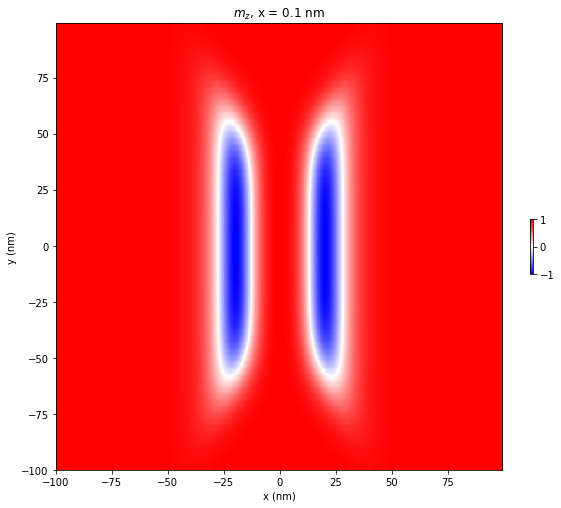

(1, 70, 200, 200, 3)
(1, 70, 200, 200, 3)


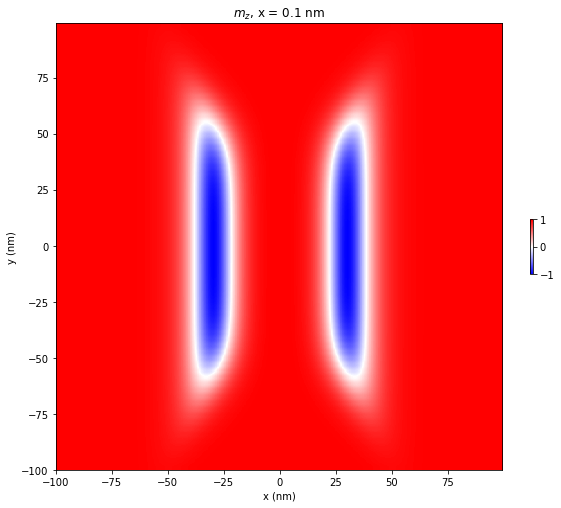

(1, 70, 200, 200, 3)
(1, 70, 200, 200, 3)


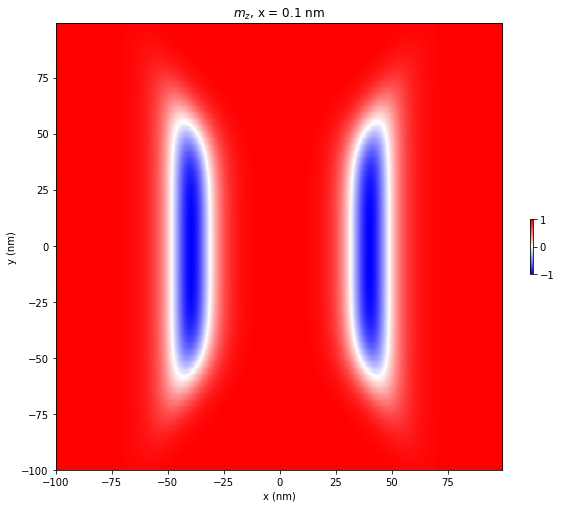

(1, 70, 200, 200, 3)
(1, 70, 200, 200, 3)


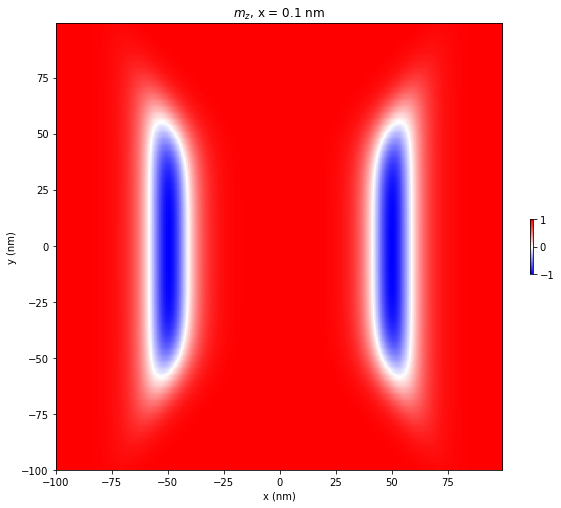

(1, 70, 200, 200, 3)
(1, 70, 200, 200, 3)


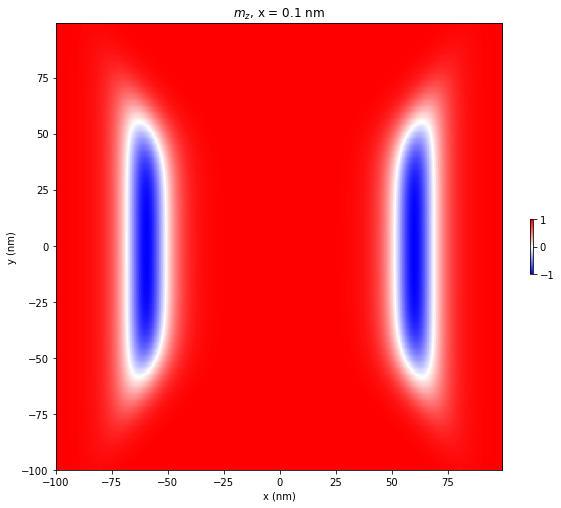

(1, 70, 200, 200, 3)
(1, 70, 200, 200, 3)


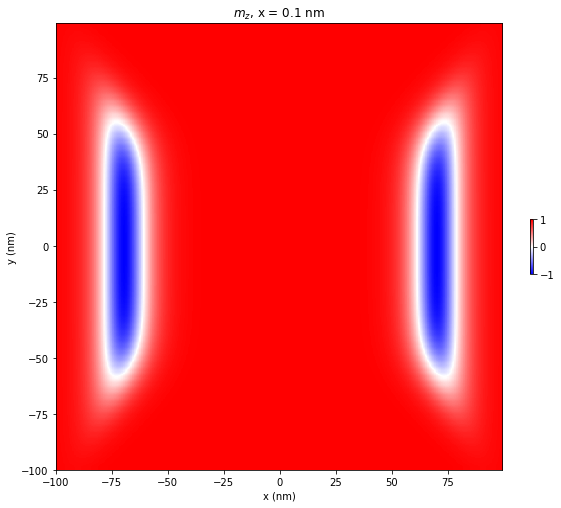

(1, 70, 200, 200, 3)
(1, 70, 200, 200, 3)


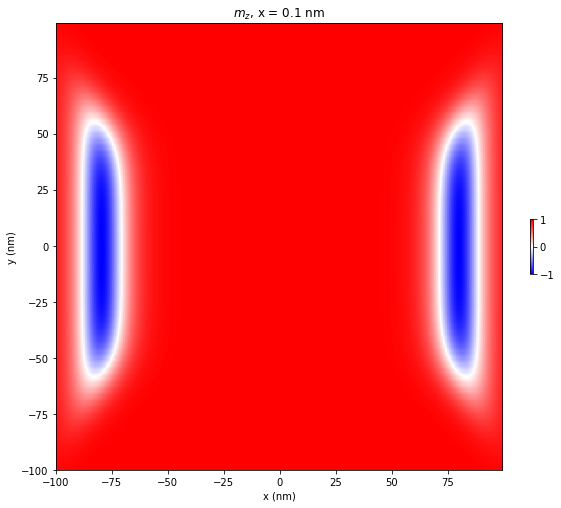

(1, 70, 200, 200, 3)
(1, 70, 200, 200, 3)


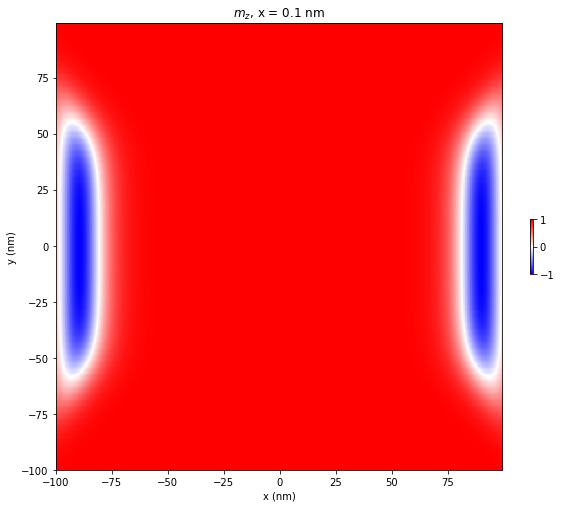

(1, 70, 200, 200, 3)


In [22]:
for R in np.arange(20, 91, 10, dtype=int):
    
    R = R*1e-9
    w_R = 10e-9

    h = 20e-9
    w_h = 7e-9

    M = np.zeros((1,z.shape[0],y.shape[0],x.shape[0],3))
    print(M.shape)

    for i in range(z.shape[0]):
        for j in range(y.shape[0]):
            for k in range(x.shape[0]):
                M[0,i,j,k,0]= m_x(x[k],y[j],z[i],w_R,w_h,h, R)
                M[0,i,j,k,1]= m_y(x[k],y[j],z[i],w_R,w_h,h, R)
                M[0,i,j,k,2]= m_z(x[k],y[j],z[i],w_R,w_h,h, R)



    i = x.shape[0]//2

    plt.figure(figsize=(10,10))
    plt.title(f"$m_z$, x = { round( x[i]*1e9,2 ) } nm")
    im = plt.imshow(  M[0,:,:,i,2], #interpolation="gaussian",
               norm=colors.Normalize(vmin=-1,vmax=1 ), extent=[x.min()*1e9,x.max()*1e9,y.min()*1e9,y.max()*1e9],cmap="bwr",     )
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    #     plt.legend()
    plt.colorbar(im,shrink=0.1)
    plt.show()

    parms = parameters.ovfParms()
    path = "./dawca_r_100_nm_h_70_nm_c_1nm.ovf"
    M_tzyxm = ovf.OvfFile(path, parms)
    print((M_tzyxm.array).shape)

    M_tzyxm.array[0,...]=M

    save_ovf_single(M_tzyxm,filename="initial_config_r_100_nm_h_70_nm_c_1nm_R_{}nm.ovf".format(int(R*1e9)),t=0)

In [14]:
# for i in range( x.shape[0] ):

#     plt.figure(figsize=(10,10))
#     plt.title(f"$m_z$, x = { round( x[i]*1e9,2 ) } nm")
#     im = plt.imshow(  M[0,:,:,i,2], #interpolation="gaussian",
#                norm=colors.Normalize(vmin=-1,vmax=1 ), extent=[x.min()*1e9,x.max()*1e9,y.min()*1e9,y.max()*1e9],cmap="bwr",     )
#     plt.xlabel("x (nm)")
#     plt.ylabel("y (nm)")
#     #     plt.legend()
#     plt.colorbar(im,shrink=0.1)
#     plt.show()

In [24]:
(5e-3/2e-9)/1e6

2.5

(1, 70, 200, 200, 3)


In [14]:
0=1

SyntaxError: cannot assign to literal (<ipython-input-14-9e7f5bcac3cc>, line 1)

# Periodic structure

In [ ]:
dx = 0.501e-9
L_x = 128e-9
L_y = 128e-9
L_z = 17e-9

x = np.arange(-L_x/2, (L_x)/2, dx)
y = np.arange(-L_y/2, (L_y)/2, dx)
z = np.arange(-L_z/2, (L_z)/2, dx)
M = np.zeros((1,z.shape[0],y.shape[0],x.shape[0],3))
print(M.shape)

In [ ]:
w_R = 5.6e-9
w_h = 1.6e-9
h = 6.3e-9
R = 8.3e-9

In [ ]:
M = np.zeros((1,z.shape[0],y.shape[0],x.shape[0],3))
print(M.shape)

# centre
for i in range(z.shape[0]):
    for j in range(y.shape[0]):
        for k in range(x.shape[0]):
            M[0,i,j,k,0] = m_x(x[k],y[j],z[i],w_R,w_h,h, R)
            M[0,i,j,k,1] = m_y(x[k],y[j],z[i],w_R,w_h,h, R)
            M[0,i,j,k,2] = m_z(x[k],y[j],z[i],w_R,w_h,h, R)


# left, up      
for i in range(   z.shape[0] ):
    for j in range(   int(y.shape[0]/4)   ):
        for k in range(   int(x.shape[0]/4)    ):            
            M[0,i,j,k,0] = m_x(x[k]+x.max(),y[j]+y.max(),z[i],w_R,w_h,h, R)
            M[0,i,j,k,1] = m_y(x[k]+x.max(),y[j]+y.max(),z[i],w_R,w_h,h, R)
            M[0,i,j,k,2] = m_z(x[k]+x.max(),y[j]+y.max(),z[i],w_R,w_h,h, R)

# right, up      
for i in range(   z.shape[0] ):
    for j in range(   int(y.shape[0]/4) ):
        for k in range(   int(3*x.shape[0]/4) , x.shape[0]   ):            
            M[0,i,j,k,0] = m_x(x[k]-x.max(),y[j]+y.max(),z[i],w_R,w_h,h, R)
            M[0,i,j,k,1] = m_y(x[k]-x.max(),y[j]+y.max(),z[i],w_R,w_h,h, R)
            M[0,i,j,k,2] = m_z(x[k]-x.max(),y[j]+y.max(),z[i],w_R,w_h,h, R)
            
# left, down                  
for i in range(   z.shape[0] ):
    for j in range(    int(3*y.shape[0]/4) , y.shape[0]  ):
        for k in range(    int(x.shape[0]/4)   ):            
            M[0,i,j,k,0] = m_x(x[k]+x.max(),y[j]-y.max(),z[i],w_R,w_h,h, R)
            M[0,i,j,k,1] = m_y(x[k]+x.max(),y[j]-y.max(),z[i],w_R,w_h,h, R)
            M[0,i,j,k,2] = m_z(x[k]+x.max(),y[j]-y.max(),z[i],w_R,w_h,h, R)
            
# right, down                  
for i in range(   z.shape[0] ):
    for j in range(   int(3*y.shape[0]/4) , y.shape[0]  ):
        for k in range(   int(3*x.shape[0]/4) , x.shape[0]   ):            
            M[0,i,j,k,0] = m_x(x[k]-x.max(),y[j]-y.max(),z[i],w_R,w_h,h, R)
            M[0,i,j,k,1] = m_y(x[k]-x.max(),y[j]-y.max(),z[i],w_R,w_h,h, R)
            M[0,i,j,k,2] = m_z(x[k]-x.max(),y[j]-y.max(),z[i],w_R,w_h,h, R)

In [ ]:
for i in range(   z.shape[0] ):

    plt.figure(figsize=(10,10))
    plt.title(f"$m_z$, z = { round( z[i]*1e9,2 ) } nm")
    im = plt.imshow(  M[0,i,:,:,2] , extent=[x.min()*1e9,x.max()*1e9,y.min()*1e9,y.max()*1e9],
                    cmap="bwr",
               norm=colors.Normalize(vmin=-1,vmax=1 ))
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")

    #     plt.axvline(x= R*1e9,c='r',ls='--',label="R")
    #     plt.axvline(x=-R*1e9,c='r',ls='--')
    #     plt.axhline(y= R*1e9,c='r',ls='--')
    #     plt.axhline(y=-R*1e9,c='r',ls='--')

    #     plt.axvline(x= w_R*1e9,c='lime',ls='--',label="w_R")
    #     plt.axvline(x=-w_R*1e9,c='lime',ls='--')
    #     plt.axhline(y= w_R*1e9,c='lime',ls='--')
    #     plt.axhline(y=-w_R*1e9,c='lime',ls='--')

    #     plt.legend()
    plt.colorbar(im,shrink=0.1)
    plt.show()

In [ ]:
parms = parameters.ovfParms()
path = "./dawca_d_128_nm_H_17_nm.ovf"
M_tzyxm = ovf.OvfFile(path, parms)
print((M_tzyxm.array).shape)

In [ ]:
M_tzyxm.array[0,...]=M

In [ ]:
save_ovf_single(M_tzyxm,filename="initial_config_d_128_nm_H_16_nm_R_8.3_nm_h_6.3_nm_triangular_a_90_nm.ovf",t=0)

In [ ]:
0=1

In [ ]:
w_R = 5.6e-9
w_h = 1.6e-9
h = 6.3e-9
R = 8.3e-9

In [ ]:
M_ring = np.zeros((1,z.shape[0],y.shape[0],x.shape[0],3))

In [ ]:
for i in range(z.shape[0]):
    for j in range(y.shape[0]):
        for k in range(x.shape[0]):
            if sqrt(x[k]**2+y[j]**2) >= R-w_R/2  and sqrt(x[k]**2+y[j]**2) <= R+w_R/2 and abs(z[i]) <= h:
                M_ring[0,i,j,k,2] = -1
            else:
                M_ring[0,i,j,k,2] = 1

In [ ]:
for i in range(z.shape[0]):
    
    plt.figure(figsize=(10,10))
    plt.title(f"$m_z$, z = { round( z[i]*1e9,2 ) } nm")
    
    plt.imshow(M_ring[0,i,:,:,2],extent=[x.min()*1e9,x.max()*1e9,y.min()*1e9,y.max()*1e9], cmap='PRGn',
               norm=colors.Normalize(vmin=-1,vmax=1)   )
    
    plt.xlabel("x (nm)")
    plt.ylabel("y (nm)")
    
    plt.axvline(x= R*1e9,c='r',ls='--',label="R")
    plt.axvline(x=-R*1e9,c='r',ls='--')
    plt.axhline(y= R*1e9,c='r',ls='--')
    plt.axhline(y=-R*1e9,c='r',ls='--')
    
    plt.axvline(x= w_R*1e9,c='lime',ls='--',label="w_R")
    plt.axvline(x=-w_R*1e9,c='lime',ls='--')
    plt.axhline(y= w_R*1e9,c='lime',ls='--')
    plt.axhline(y=-w_R*1e9,c='lime',ls='--')
    
    plt.legend()

    plt.show()

In [ ]:
parms = parameters.ovfParms()
path = "./dawca.ovf"
M_tzyxm = ovf.OvfFile(path, parms)
print((M_tzyxm.array).shape)

In [ ]:
M_tzyxm.array[0,...]=M_ring

In [ ]:
save_ovf_single(M_tzyxm,filename="initial_config_ring.ovf",t=0)

## Mirror reflection of the magnetic state

In [ ]:
parms = parameters.ovfParms()
path = "./simulations/bloch_hopfion_sweep.out/Ku_b_41_kJ_m3_D_128_muJ_m2.ovf"
M_tzyxm = ovf.OvfFile(path, parms)
print((M_tzyxm.array).shape)

In [ ]:
x = np.arange(0, (M_tzyxm.array).shape[2],1)*0.5e-9
x = x-np.mean(x)
y = np.arange(0, (M_tzyxm.array).shape[3],1)*0.5e-9
y = y-np.mean(y)

In [ ]:
color_map = M_tzyxm.array[0,17,:,:,2]

In [ ]:
plt.imshow(color_map,
           origin="lower", aspect=1,                                      #LogNorm(),
           extent=[np.amin(x)*1e6,np.amax(x)*1e6, np.amin(y)*1e6,np.amax(y)*1e6])

In [ ]:
M = np.zeros((M_tzyxm.array).shape)

In [ ]:
for i in range(34):
    for j in range(3):
        
        color_map = M_tzyxm.array[0,i,:,:,j]
        color_map_i = list(zip(*color_map[::-1]))
        M[0,i,:,:,j] = color_map_i

In [ ]:
plt.imshow(M[0,17,:,:,0],
           origin="lower", aspect=1,                                      #LogNorm(),
           extent=[np.amin(x)*1e6,np.amax(x)*1e6, np.amin(y)*1e6,np.amax(y)*1e6])

In [ ]:
parms = parameters.ovfParms()
path = "./rotation/dawca.ovf"
M_tzyxm = ovf.OvfFile(path, parms)
print((M_tzyxm.array).shape)

In [ ]:
M_tzyxm.array[0,...]=M

In [ ]:
# save_ovf_single(M_tzyxm,filename=r".rotated.ovf",t=0)

## Rotation of the magnetic configuration by given angle

In [ ]:
from scipy import ndimage, misc

In [ ]:
parms = parameters.ovfParms()
path = "./simulations/bloch_hopfion_sweep.out/Ku_b_41_kJ_m3_D_128_muJ_m2.ovf"
M_tzyxm = ovf.OvfFile(path, parms)
print((M_tzyxm.array).shape)

In [ ]:
M = np.zeros((M_tzyxm.array).shape)

In [ ]:
x = np.arange(0, (M_tzyxm.array).shape[2],1)*0.5e-9
x = x-np.mean(x)
y = np.arange(0, (M_tzyxm.array).shape[3],1)*0.5e-9
y = y-np.mean(y)
z = np.arange(0, (M_tzyxm.array).shape[1],1)*0.501e-9
z = z-np.mean(z)

In [ ]:
angle = 5

In [ ]:
for i in range(34):
    for j in range(3):
        
        color_map = M_tzyxm.array[0,i,:,:,j]
        color_map_i = ndimage.rotate(color_map, angle, axes=(1, 0))
        M[0,i,:,:,j] = color_map_i[   int(color_map_i.shape[0]/2)-128:int(color_map_i.shape[0]/2)+128, int(color_map_i.shape[1]/2)-128:int(color_map_i.shape[1]/2)+128]

In [ ]:
for i in [17]:
    plt.title(f"z = {round(z[i]*1e9,2)} nm")
    plt.imshow(M[0,i,:,:,2],
           origin="lower", aspect=1,      norm=colors.Normalize(vmin=-1,vmax=1 ),                                #LogNorm(),
           extent=[np.amin(x)*1e6,np.amax(x)*1e6, np.amin(y)*1e6,np.amax(y)*1e6]
          )
    plt.show()

In [ ]:
parms = parameters.ovfParms()
path = "./rotation/dawca.ovf"
M_tzyxm = ovf.OvfFile(path, parms)
print((M_tzyxm.array).shape)

In [ ]:
M_tzyxm.array[0,...]=M

In [ ]:
save_ovf_single(M_tzyxm,filename=r"rotated_{}_deg.ovf".format(angle),t=0)

In [ ]:
0.06*1000

In [ ]:
np.arctan(0.5/60)*180/np.pi